#### Université Paul Sabatier  2022-2023, L3
# Simulations stochastiques - TP4 sur le TD4

In [9]:
%matplotlib inline
from matplotlib.pyplot import *
from math import *
from numpy import *
from numpy.random import *
from scipy.misc import *
from scipy.stats import *

## Exercice 1 du TD4
On considère une suite $(X_k)_{k \geq 1}$ de variables aléatoires indépendantes et identiquement distribuées, dont la loi a pour densité $f:\mathbb{R} \to \mathbb{R}_+$ définie par
$$                                                                         
f(x) = \left \{ \begin{array}{ll}                                               
        0 & \textrm{si $x<0$} \\                                                
        x e^{-x} & \textrm{si $x \geq 0$}                                       
\end{array} \right.                                                             
$$
* 4) Montrer que la loi de $X_1$ admet une densité par rapport à la loi exponentielle de paramètre 1/2. Montrer que cette densité est bornée par $4/e$.

Réponse densité : $2xe^{-x/2}$ sur $\mathbb{R}_+$.

* 5) Rappeler comment simuler une variable exponentielle de paramètre 1/2. En se basant sur la question 4, utiliser la méthode du rejet pour donner une simulation de $(X_k)_{1\leq k\leq 10000}$.


In [10]:
def rexo1(N): # On l'utilisera pour N=10**4, puis pour n=1000 à la question 8
    X=-2*log(rand(N))
    for i in range(N):
        while rand()>X[i]*exp(1-X[i]/2)/2:
            X[i]=-2*log(rand())
    return X

In [11]:
rexo1(10**4)

array([3.00244958, 5.49583887, 1.9370394 , ..., 1.71897754, 0.68603051,
       0.10165013])

 Comparer l'histogramme et $f$ et vérifier la convergence de $\bar{X}_n$.

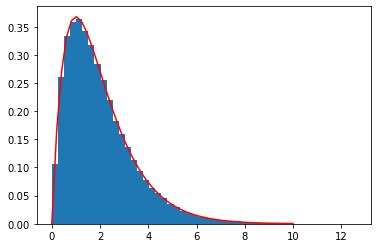

In [12]:
N=10**5
X=rexo1(N)
hist(X,density=True,bins=50)
xx=linspace(0,10)
plot(xx,xx*exp(-xx),'r')

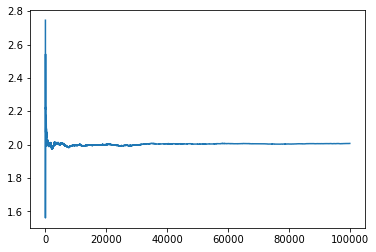

In [13]:
#Représenter n->Xnbarre
plot(cumsum(X)/range(1,N+1))

* 7) En déduire (Bienaymé-Tchebychev du 6) que l'intervalle aléatoire
$$
I_n = \left[\bar{X}_n - \frac{3}{\sqrt{n}}, \bar{X}_n + \frac{3}{\sqrt{n}} \right]
$$                                                             
contient la valeur de $\mathbb{E}(X_1)$ avec probabilité supérieure ou égale à $75\%$.
* 8) Réaliser $N=500$ simulations de $\bar{X}_n$ pour $n = 1000$. Donner une approximation de la probabilité de l'évènement $\mathbb{E}(X_1) \in I_n$. Faites le lien avec la borne donnée question précédente. Commenter le caractère conservatif de cette borne.

In [14]:
N=1000
n=100
Y=zeros(N)
for i in range(N):
    Y[i]=sum(rexo1(n))/n
mean(abs(2-Y)<3/sqrt(n))

## borne BT très large (très conservative) (la "vraie proba" est largement > 75%)
#### RM : par rapport à l'énoncé, inutile de prendre n très grand, la cv est rapide dans le TCL.
### Mais prendre N grand : la LGN le nécessite pour obtenir un histogramme proche de la densité gaussienne. 

0.962

* 9) Enoncer le théorème central limite pour $\bar{X}_n$. Utiliser votre dernière simulation pour illustrer graphiquement ce résultat. Proposer une borne moins conservative que celle de la question 7 et compararer au résultat de la question 8.


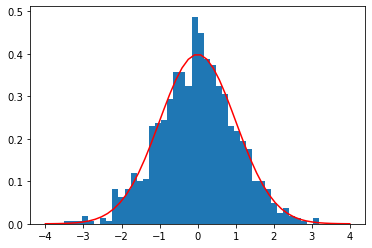

0.9661051464753108


In [15]:
hist(sqrt(n/2)*(Y-2),density=True,bins=linspace(-4,4,51))
xx=linspace(-4,4)
plot(xx,exp(-xx**2/2)/sqrt(2*pi),'r')
show()
print(norm.cdf(3/sqrt(2))-norm.cdf(-3/sqrt(2)))

Quelques exemples de la librairie `scipy.stats` :

In [16]:
print(expon.pdf(1))
print(poisson.pmf(0,1))
print(poisson.cdf(1,1))
print(norm.ppf(0.975))

0.36787944117144233
0.36787944117144233
0.7357588823428847
1.959963984540054
